In [1]:
import os, subprocess
from pathlib import Path

# ── Find AD/CN/MCI root ─────────────────────────────────────────────────────

GDRIVE_FILE_ID = '1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz'
WORK_DIR = Path('/kaggle/working')

TARGET_CLASSES = {'AD', 'CN', 'MCI'}

def find_adni_root(search_roots):
    """
    Check at most 2 levels deep (root itself, then its direct children).
    This avoids picking up the tensor-cache directory
    (/kaggle/working/preprocessed_*/train/AD …) which is 3 levels deep.
    """
    for sr in search_roots:
        sr = Path(sr)
        if not sr.exists():
            continue
        try:
            subdirs = {d for d in os.listdir(sr) if os.path.isdir(sr / d)}
            if TARGET_CLASSES.issubset(subdirs):
                return str(sr)
        except PermissionError:
            pass
        try:
            for sub in sorted(os.listdir(sr)):
                sub_path = sr / sub
                if not sub_path.is_dir():
                    continue
                try:
                    subdirs = {d for d in os.listdir(sub_path) if (sub_path / d).is_dir()}
                    if TARGET_CLASSES.issubset(subdirs):
                        return str(sub_path)
                except PermissionError:
                    pass
        except PermissionError:
            pass
    return None

# --- Search /kaggle/input first (Kaggle dataset attached via "Add Data") ---
ADNI_DIR = find_adni_root(['/kaggle/input/datasets/faridaali202301940/draftdata/adni_nifti_preprocessed'])

# --- Then /kaggle/working (previous gdown download) ---
if ADNI_DIR is None:
    ADNI_DIR = find_adni_root([WORK_DIR])

# --- Download if still not found ---
if ADNI_DIR is None:
    ADNI_ZIP_PATH = WORK_DIR / 'adni_dataset.zip'
    print('Dataset not found locally — downloading via gdown ...')
    subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
    import gdown
    gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}', str(ADNI_ZIP_PATH), quiet=False)
    import zipfile
    with zipfile.ZipFile(str(ADNI_ZIP_PATH), 'r') as zf:
        zf.extractall(str(WORK_DIR))
    ADNI_ZIP_PATH.unlink(missing_ok=True)
    ADNI_DIR = find_adni_root([WORK_DIR])

if ADNI_DIR is None:
    raise RuntimeError(
        'Could not find a directory containing AD, CN, MCI subfolders.\n'
        'Options:\n'
        '  1. Add the Alzheimer dataset via Kaggle "Add Data" (fastest).\n'
        '  2. Set GDRIVE_FILE_ID to your own Google Drive zip.\n'
        '  3. Manually set ADNI_DIR below.'
    )

print(f'ADNI_DIR = {ADNI_DIR}')

for cls in sorted(TARGET_CLASSES):
    cls_path = os.path.join(ADNI_DIR, cls)
    n = sum(len(f) for _, _, f in os.walk(cls_path)) if os.path.isdir(cls_path) else 0
    print(f'  {cls}: ~{n} files')


Dataset not found locally — downloading via gdown ...


Downloading...
From (original): https://drive.google.com/uc?id=1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz
From (redirected): https://drive.google.com/uc?id=1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz&confirm=t&uuid=6c133b15-c22f-41c9-89c2-f002a367d15b
To: /kaggle/working/adni_dataset.zip
100%|██████████| 387M/387M [00:03<00:00, 129MB/s]  


ADNI_DIR = /kaggle/working/adni_nifti_preprocessed
  AD: ~1434 files
  CN: ~2341 files
  MCI: ~4737 files


In [2]:
import os
import csv
import random
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.metrics import confusion_matrix, classification_report

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
DATA_ROOT  = ADNI_DIR
OUTPUT_DIR = '/kaggle/working/preprocessed_densenet121_patientlevel'
CKPT_DIR   = '/kaggle/working/checkpoints_densenet121_patientlevel'
os.makedirs(CKPT_DIR, exist_ok=True)

In [6]:
IMAGE_SIZE = 224
N_FOLDS = 5
BATCH_SIZE = 32
NUM_EPOCHS = 40
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 10
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [7]:
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
print(f"Classes found: {CLASS_NAMES}")

Classes found: ['AD', 'CN', 'MCI']


# Checking Patients & Leakage

In [8]:
patient_classes = defaultdict(set)
patient_slices = defaultdict(list)

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(cls_dir):
        print(f"[WARNING] Missing class folder: {cls_dir}")
        continue
    for patient_id in os.listdir(cls_dir):
        patient_dir = os.path.join(cls_dir, patient_id)
        if not os.path.isdir(patient_dir):
            continue
        slices = [
            os.path.join(patient_dir, f)
            for f in os.listdir(patient_dir)
            if os.path.splitext(f)[1].lower() in VALID_EXTS
        ]
        if slices:
            patient_classes[patient_id].add(cls)
            patient_slices[(patient_id, cls)].extend(slices)

print(f"Total unique patients: {len(patient_classes)}")

Total unique patients: 320


In [9]:
leakage_patients = {
    pid: classes
    for pid, classes in patient_classes.items()
    if len(classes) > 1
}

print(f"\n{'='*55}")
print(f"  LEAKAGE CHECK")
print(f"{'='*55}")
if leakage_patients:
    print(f"  Patients in multiple classes (EXCLUDED): {len(leakage_patients)}")
    for pid, classes in sorted(leakage_patients.items()):
        print(f"    {pid}  ->  {sorted(classes)}")
else:
    print("  No patients in multiple classes. Dataset is clean.")

clean_patients = {
    pid: list(classes)[0]
    for pid, classes in patient_classes.items()
    if pid not in leakage_patients
}
print(f"\n  Patients kept    : {len(clean_patients)}")
print(f"  Patients excluded: {len(leakage_patients)}")


  LEAKAGE CHECK
  No patients in multiple classes. Dataset is clean.

  Patients kept    : 320
  Patients excluded: 0


# Hold-out Test Set (PATIENT-LEVEL, STRATIFIED)

In [10]:
TEST_RATIO = 0.15

class_patients = defaultdict(list)
for pid, cls in clean_patients.items():
    class_patients[cls].append(pid)

for cls in CLASS_NAMES:
    random.shuffle(class_patients[cls])

test_patients = []
trainval_patients = []

print(f"\n{'='*55}")
print(f"  HOLD-OUT TEST SET (stratified by class)")
print(f"{'='*55}")

for cls in CLASS_NAMES:
    pids = class_patients[cls]
    n_test = max(1, int(len(pids) * TEST_RATIO))
    test_patients.extend(pids[:n_test])
    trainval_patients.extend(pids[n_test:])
    print(f"  {cls}: {len(pids)} total  |  test={n_test}  |  train+val pool={len(pids)-n_test}")

assert not (set(test_patients) & set(trainval_patients)), "Test/trainval overlap!"
print(f"\n  Test patients     : {len(test_patients)}")
print(f"  Train+Val patients: {len(trainval_patients)}")
print(f"  Total             : {len(test_patients)+len(trainval_patients)}")

test_entries = []
for pid in test_patients:
    cls = clean_patients[pid]
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]:
        test_entries.append((path, label, pid))

print(f"  Test slices       : {len(test_entries)}")


  HOLD-OUT TEST SET (stratified by class)
  AD: 54 total  |  test=8  |  train+val pool=46
  CN: 88 total  |  test=13  |  train+val pool=75
  MCI: 178 total  |  test=26  |  train+val pool=152

  Test patients     : 47
  Train+Val patients: 273
  Total             : 320
  Test slices       : 1250


# Preprocessing & Saving Slices

In [11]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_entries = []
for pid, cls in clean_patients.items():
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]:
        all_entries.append((path, label, pid))

fname_counts = {}

def preprocess_and_save(entries, desc="Saving"):
    for path, label, pid in tqdm(entries, desc=desc):
        cls_name = CLASS_NAMES[label]
        out_dir = os.path.join(OUTPUT_DIR, cls_name)
        os.makedirs(out_dir, exist_ok=True)

        base = os.path.splitext(os.path.basename(path))[0]
        key = f"{pid}_{base}"
        fname_counts[key] = fname_counts.get(key, 0) + 1
        suffix = f"_dup{fname_counts[key]}" if fname_counts[key] > 1 else ""
        out_path = os.path.join(out_dir, f"{key}{suffix}.pt")

        if not os.path.exists(out_path):
            img = Image.open(path).convert("L")
            img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
            tensor = transforms.ToTensor()(img)
            tensor = (tensor * 255).byte().repeat(3, 1, 1)
            torch.save(tensor, out_path)

preprocess_and_save(all_entries, desc="Preprocessing all slices")
print(f"Done. {len(all_entries)} slices saved to {OUTPUT_DIR}")

Preprocessing all slices: 100%|██████████| 8512/8512 [00:19<00:00, 432.27it/s]

Done. 8512 slices saved to /kaggle/working/preprocessed_densenet121_patientlevel


In [12]:
pt_lookup = {}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(OUTPUT_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in os.listdir(cls_dir):
        if fname.endswith(".pt"):
            stem = fname[:-3]
            pt_lookup[stem] = os.path.join(cls_dir, fname)

print(f"pt_lookup built: {len(pt_lookup)} entries")

pt_lookup built: 8512 entries


# Dataset Class & Augmentation

In [13]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

train_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

class SliceDataset(Dataset):
    def __init__(self, entries, augment=False):
        self.samples = []
        self.augment = augment
        for path, label, pid in entries:
            cls_name = CLASS_NAMES[label]
            base = os.path.splitext(os.path.basename(path))[0]
            key = f"{pid}_{base}"

            if key in pt_lookup:
                self.samples.append((pt_lookup[key], label, pid))
            else:
                found = False
                for dup_idx in range(2, 50):
                    dup_key = f"{key}_dup{dup_idx}"
                    if dup_key in pt_lookup:
                        self.samples.append((pt_lookup[dup_key], label, pid))
                        found = True
                        break

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pt_path, label, pid = self.samples[idx]
        tensor = torch.load(pt_path, weights_only=True).float() / 255.0
        if self.augment:
            tensor = train_augment(tensor)
        return normalize(tensor), label, pid

    def get_labels(self):
        return [s[1] for s in self.samples]

print("SliceDataset class defined.")

SliceDataset class defined.


#Model

In [14]:
def build_densenet121(num_classes):
    """
    DenseNet-121 from torchvision.models
    Paper reports this achieved 86.55% average performance
    """
    model = models.densenet121(weights=False)  # Start from scratch as per paper

    # Replace classifier for binary classification
    num_features = model.classifier.in_features
    model.classifier = nn.Linear(num_features, num_classes)

    # Initialize the new classifier layer
    nn.init.xavier_uniform_(model.classifier.weight)
    nn.init.zeros_(model.classifier.bias)

    return model

print("DenseNet-121 model builder defined.")

DenseNet-121 model builder defined.


# Training Utilities

In [15]:
def run_epoch(loader, model, criterion, optimizer=None, scaler=None, desc=""):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with (torch.enable_grad() if is_train else torch.no_grad()):
        for batch in tqdm(loader, desc=desc, leave=False):
            images, labels, _ = batch
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            correct += (outputs.argmax(1) == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)

    return total_loss / total, correct / total

In [16]:
def patient_level_eval(loader, model, binary_names):
    model.eval()
    patient_probs = defaultdict(list)
    patient_labels = {}

    with torch.no_grad():
        for images, labels, pids in tqdm(loader, desc="Patient-eval", leave=False):
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast(device_type="cuda"):
                logits = model(images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            for prob, label, pid in zip(probs, labels.numpy(), pids):
                patient_probs[pid].append(prob)
                patient_labels[pid] = int(label)

    all_true, all_pred = [], []
    for pid, probs_list in patient_probs.items():
        avg_prob = np.mean(probs_list, axis=0)
        pred_label = int(np.argmax(avg_prob))
        all_true.append(patient_labels[pid])
        all_pred.append(pred_label)

    acc = np.mean(np.array(all_true) == np.array(all_pred))
    return acc, all_true, all_pred

print("Training utilities defined.")

Training utilities defined.


# K-Fold Cross Validation (Train & Val)


  AD vs REST  —  5-Fold Cross-Validation

  --- Fold 1/5 ---
  Train slices — AD: 961 | REST: 4826 | Val patients: 56


  Ep 01 | train loss=0.4651 acc=50.1% | val loss=1.3639 acc=17.6%
    ✓ Best val_acc=17.56% — saved.


  Ep 02 | train loss=0.4136 acc=50.5% | val loss=1.3856 acc=19.1%
    ✓ Best val_acc=19.12% — saved.


  Ep 03 | train loss=0.3948 acc=52.7% | val loss=1.2828 acc=30.0%
    ✓ Best val_acc=30.03% — saved.


  Ep 04 | train loss=0.3652 acc=60.3% | val loss=1.9867 acc=20.6%


...

  Ep 17 | train loss=0.1187 acc=90.6% | val loss=1.2880 acc=66.2%


  Ep 18 | train loss=0.1128 acc=91.4% | val loss=1.1072 acc=69.3%


  Ep 19 | train loss=0.1125 acc=91.5% | val loss=2.0482 acc=49.1%


  Ep 20 | train loss=0.0942 acc=92.8% | val loss=1.3516 acc=63.5%


  Ep 21 | train loss=0.0985 acc=92.8% | val loss=1.7726 acc=56.2%
    Early stopping at epoch 21.


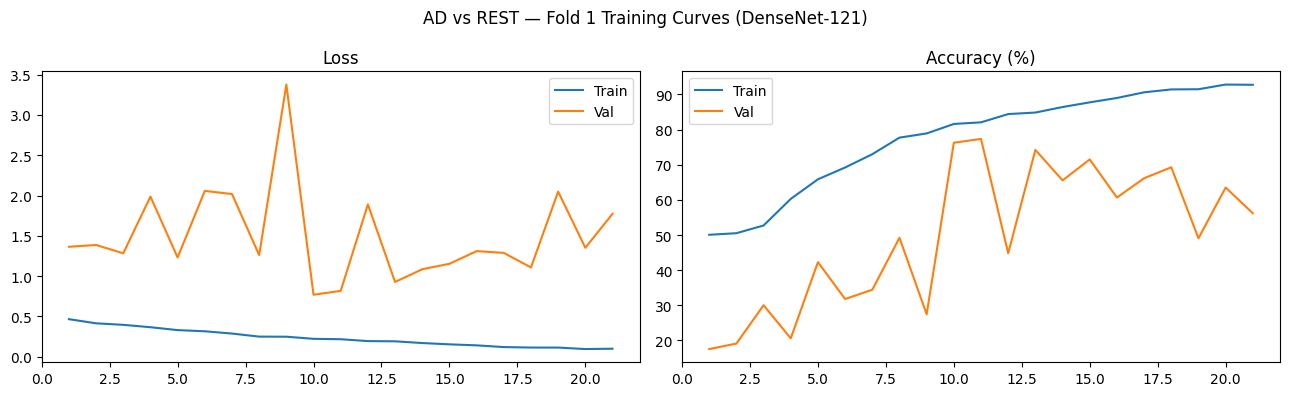

  Fold 1 — Patient-level val acc: 78.57%

  --- Fold 2/5 ---
  Train slices — AD: 979 | REST: 4816 | Val patients: 55


  Ep 01 | train loss=0.4449 acc=50.9% | val loss=1.3525 acc=16.8%
    ✓ Best val_acc=16.84% — saved.


  Ep 02 | train loss=0.4165 acc=51.7% | val loss=1.2739 acc=21.3%
    ✓ Best val_acc=21.27% — saved.


  Ep 03 | train loss=0.3963 acc=54.8% | val loss=1.3239 acc=24.6%
    ✓ Best val_acc=24.61% — saved.


  Ep 04 | train loss=0.3770 acc=58.8% | val loss=0.9990 acc=43.8%
    ✓ Best val_acc=43.83% — saved.


...

  Ep 20 | train loss=0.1541 acc=87.5% | val loss=0.9463 acc=68.5%


  Ep 21 | train loss=0.1458 acc=88.3% | val loss=1.4967 acc=50.9%


  Ep 22 | train loss=0.1312 acc=89.3% | val loss=1.0271 acc=65.8%


  Ep 23 | train loss=0.1226 acc=89.9% | val loss=0.9915 acc=67.3%


  Ep 24 | train loss=0.1195 acc=89.8% | val loss=1.2411 acc=59.6%
    Early stopping at epoch 24.


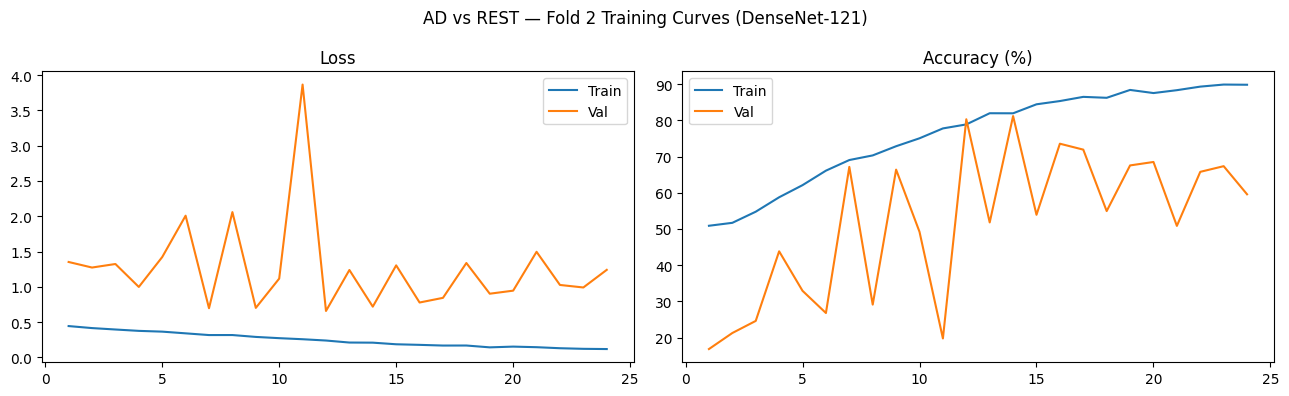

  Fold 2 — Patient-level val acc: 83.64%

  --- Fold 3/5 ---
  Train slices — AD: 979 | REST: 4837 | Val patients: 54


  Ep 01 | train loss=0.4614 acc=49.2% | val loss=1.2290 acc=17.2%
    ✓ Best val_acc=17.15% — saved.


  Ep 02 | train loss=0.4257 acc=50.4% | val loss=1.3031 acc=20.7%
    ✓ Best val_acc=20.75% — saved.


  Ep 03 | train loss=0.3780 acc=56.2% | val loss=1.4346 acc=27.5%
    ✓ Best val_acc=27.46% — saved.


  Ep 04 | train loss=0.3637 acc=61.0% | val loss=1.0733 acc=41.6%
    ✓ Best val_acc=41.56% — saved.


...

  Ep 22 | train loss=0.0902 acc=93.4% | val loss=1.0803 acc=74.9%


  Ep 23 | train loss=0.0771 acc=94.3% | val loss=1.1816 acc=74.2%


  Ep 24 | train loss=0.0797 acc=94.3% | val loss=1.1051 acc=72.2%


  Ep 25 | train loss=0.0709 acc=94.9% | val loss=1.0986 acc=76.4%


  Ep 26 | train loss=0.0627 acc=95.9% | val loss=1.2159 acc=77.1%
    Early stopping at epoch 26.


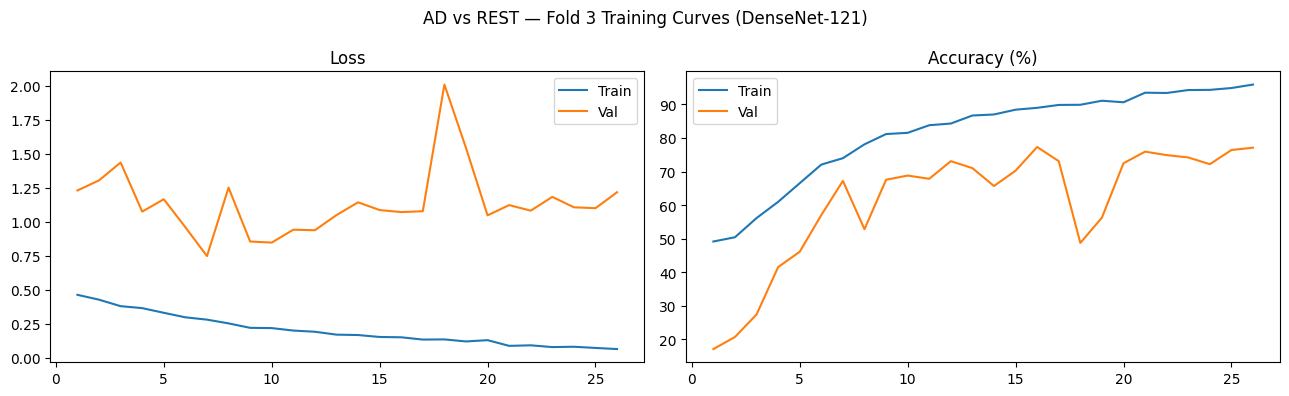

  Fold 3 — Patient-level val acc: 75.93%

  --- Fold 4/5 ---
  Train slices — AD: 984 | REST: 4852 | Val patients: 54


  Ep 01 | train loss=0.4564 acc=50.5% | val loss=1.6657 acc=16.5%
    ✓ Best val_acc=16.55% — saved.


  Ep 02 | train loss=0.4297 acc=50.3% | val loss=1.2326 acc=18.0%
    ✓ Best val_acc=17.95% — saved.


  Ep 03 | train loss=0.4183 acc=52.6% | val loss=1.2896 acc=20.8%
    ✓ Best val_acc=20.83% — saved.


  Ep 04 | train loss=0.3877 acc=56.7% | val loss=0.9531 acc=40.7%
    ✓ Best val_acc=40.67% — saved.


...

  Ep 22 | train loss=0.1266 acc=89.9% | val loss=0.7319 acc=76.9%


  Ep 23 | train loss=0.1242 acc=90.4% | val loss=0.8185 acc=82.0%


  Ep 24 | train loss=0.1199 acc=90.2% | val loss=0.8304 acc=82.1%


  Ep 25 | train loss=0.1169 acc=90.5% | val loss=0.7457 acc=79.2%


  Ep 26 | train loss=0.1003 acc=91.6% | val loss=0.9302 acc=73.7%
    Early stopping at epoch 26.


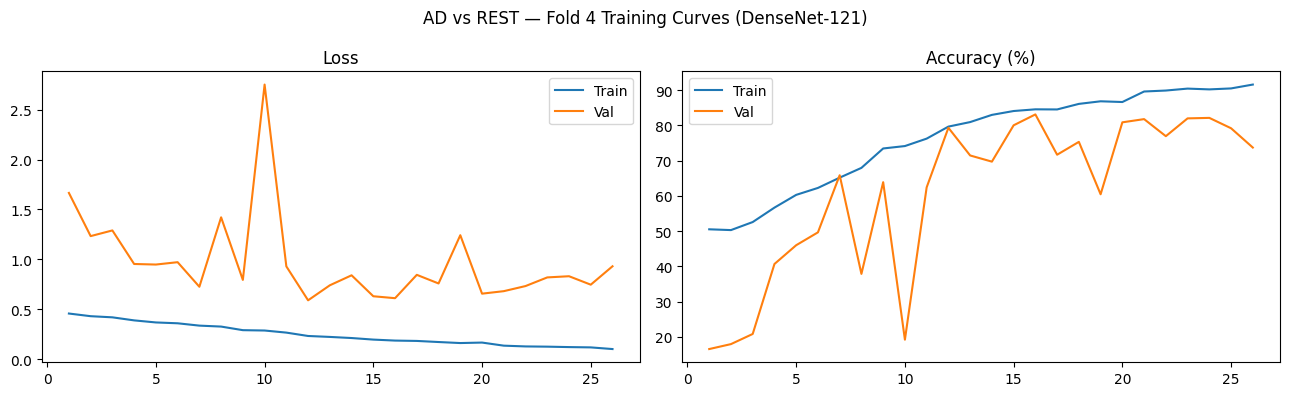

  Fold 4 — Patient-level val acc: 83.33%

  --- Fold 5/5 ---
  Train slices — AD: 977 | REST: 4837 | Val patients: 54


  Ep 01 | train loss=0.4480 acc=49.8% | val loss=1.3253 acc=18.4%
    ✓ Best val_acc=18.44% — saved.


  Ep 02 | train loss=0.3997 acc=53.4% | val loss=1.2203 acc=25.4%
    ✓ Best val_acc=25.41% — saved.


  Ep 03 | train loss=0.3883 acc=56.3% | val loss=1.3293 acc=29.1%
    ✓ Best val_acc=29.14% — saved.


  Ep 04 | train loss=0.3659 acc=60.5% | val loss=1.6283 acc=29.1%


...

  Ep 25 | train loss=0.0962 acc=93.4% | val loss=0.9851 acc=81.4%


  Ep 26 | train loss=0.0750 acc=94.2% | val loss=0.9829 acc=69.5%


  Ep 27 | train loss=0.0773 acc=94.7% | val loss=1.0498 acc=82.2%


  Ep 28 | train loss=0.0735 acc=94.4% | val loss=0.9950 acc=82.0%


  Ep 29 | train loss=0.0659 acc=95.3% | val loss=1.0254 acc=69.1%
    Early stopping at epoch 29.


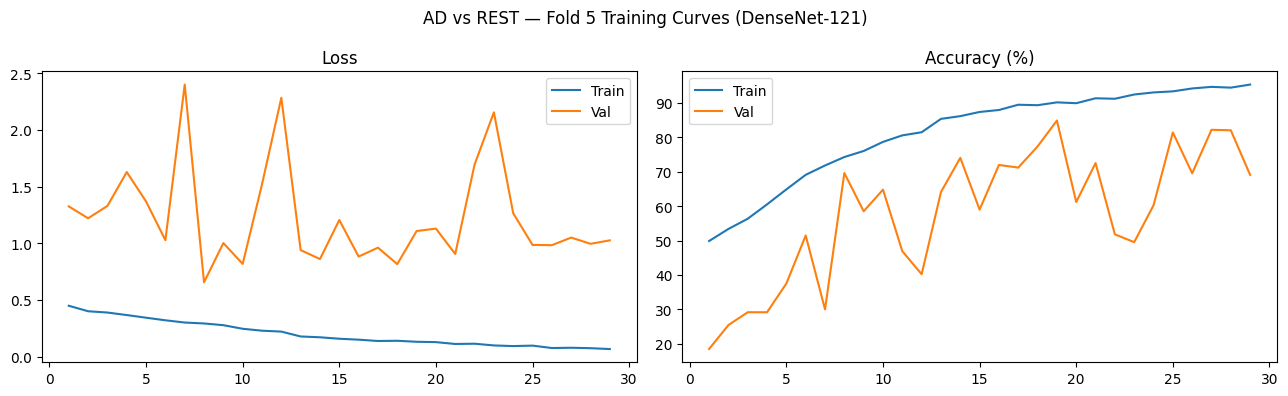

  Fold 5 — Patient-level val acc: 87.04%

  AD vs REST — 5-Fold CV Patient Acc: 81.70% ± 3.95%

  CN vs REST  —  5-Fold Cross-Validation

  --- Fold 1/5 ---
  Train slices — CN: 1604 | REST: 4183 | Val patients: 56


  Ep 01 | train loss=0.5885 acc=51.0% | val loss=0.7712 acc=31.1%
    ✓ Best val_acc=31.12% — saved.


  Ep 02 | train loss=0.5649 acc=51.8% | val loss=0.7351 acc=47.9%
    ✓ Best val_acc=47.93% — saved.


  Ep 03 | train loss=0.5222 acc=60.3% | val loss=0.6085 acc=65.1%
    ✓ Best val_acc=65.08% — saved.


  Ep 04 | train loss=0.4974 acc=64.6% | val loss=0.7574 acc=52.0%


...

  Ep 11 | train loss=0.3670 acc=78.2% | val loss=1.0229 acc=47.3%


  Ep 12 | train loss=0.3654 acc=79.1% | val loss=0.7924 acc=58.2%


  Ep 13 | train loss=0.3416 acc=80.4% | val loss=0.7124 acc=66.1%


  Ep 14 | train loss=0.3339 acc=81.0% | val loss=0.7886 acc=61.2%


  Ep 15 | train loss=0.3105 acc=82.3% | val loss=0.7974 acc=61.7%
    Early stopping at epoch 15.


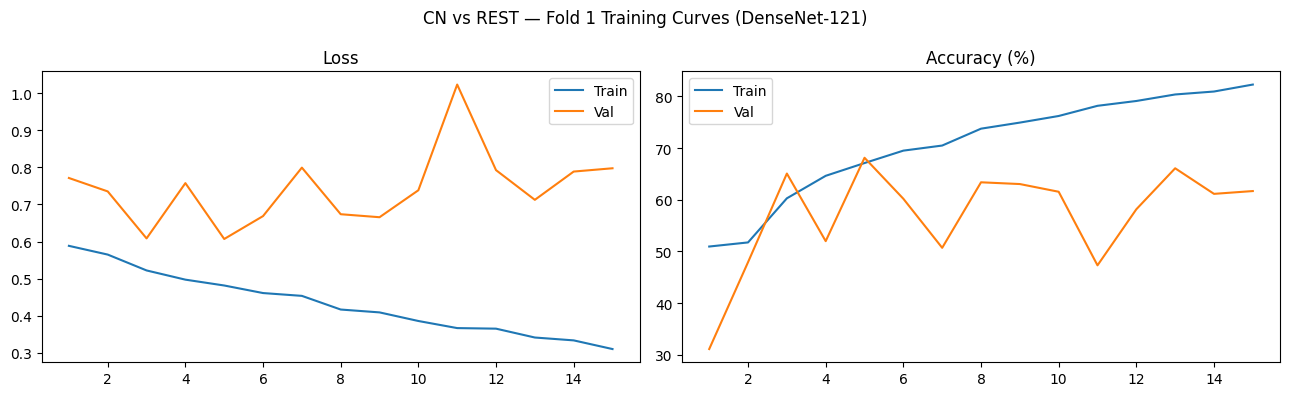

  Fold 1 — Patient-level val acc: 75.00%

  --- Fold 2/5 ---
  Train slices — CN: 1604 | REST: 4191 | Val patients: 55


  Ep 01 | train loss=0.5944 acc=51.3% | val loss=1.1509 acc=27.5%
    ✓ Best val_acc=27.47% — saved.


  Ep 04 | train loss=0.5234 acc=60.8% | val loss=1.1140 acc=36.6%
    ✓ Best val_acc=36.61% — saved.


  Ep 05 | train loss=0.5023 acc=64.4% | val loss=0.7973 acc=50.5%
    ✓ Best val_acc=50.51% — saved.


  Ep 06 | train loss=0.4827 acc=67.5% | val loss=0.6395 acc=64.3%
    ✓ Best val_acc=64.28% — saved.


...

  Ep 24 | train loss=0.1625 acc=91.6% | val loss=1.2064 acc=58.2%


  Ep 25 | train loss=0.1627 acc=91.4% | val loss=1.0158 acc=69.7%


  Ep 26 | train loss=0.1496 acc=92.5% | val loss=1.0109 acc=72.9%


  Ep 27 | train loss=0.1479 acc=92.5% | val loss=1.0247 acc=68.3%


  Ep 28 | train loss=0.1413 acc=93.0% | val loss=1.0867 acc=74.5%
    Early stopping at epoch 28.


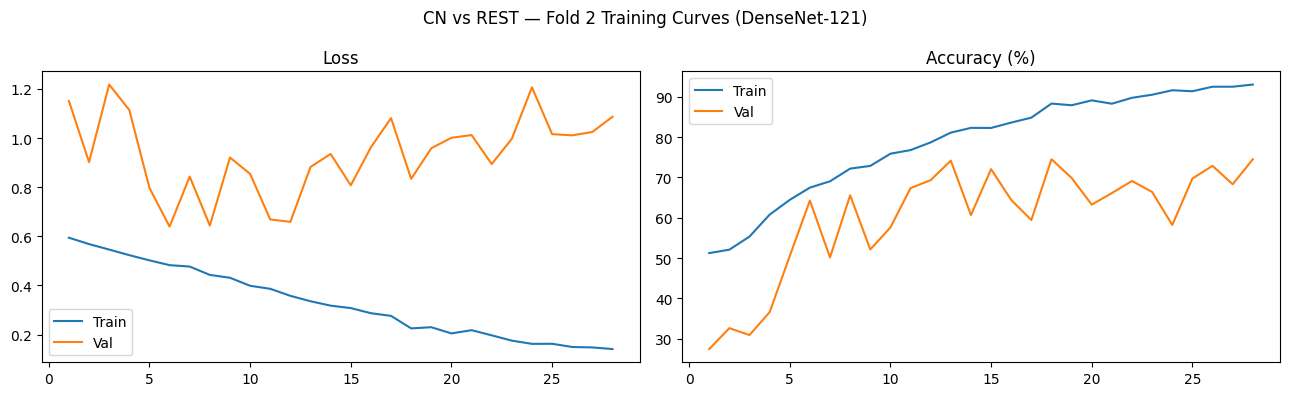

  Fold 2 — Patient-level val acc: 78.18%

  --- Fold 3/5 ---
  Train slices — CN: 1602 | REST: 4214 | Val patients: 54


  Ep 01 | train loss=0.5949 acc=50.7% | val loss=1.0677 acc=27.9%
    ✓ Best val_acc=27.94% — saved.


  Ep 02 | train loss=0.5267 acc=56.1% | val loss=1.0806 acc=34.2%
    ✓ Best val_acc=34.23% — saved.


  Ep 03 | train loss=0.5013 acc=63.2% | val loss=1.0451 acc=48.1%
    ✓ Best val_acc=48.13% — saved.


  Ep 04 | train loss=0.4881 acc=65.5% | val loss=1.2132 acc=44.1%


...

  Ep 18 | train loss=0.2212 acc=88.0% | val loss=1.0861 acc=71.1%


  Ep 19 | train loss=0.2009 acc=88.6% | val loss=1.2251 acc=69.8%


  Ep 20 | train loss=0.1925 acc=89.6% | val loss=1.6268 acc=71.0%


  Ep 21 | train loss=0.1745 acc=90.5% | val loss=1.0578 acc=71.0%


  Ep 22 | train loss=0.1730 acc=90.7% | val loss=1.1904 acc=67.8%
    Early stopping at epoch 22.


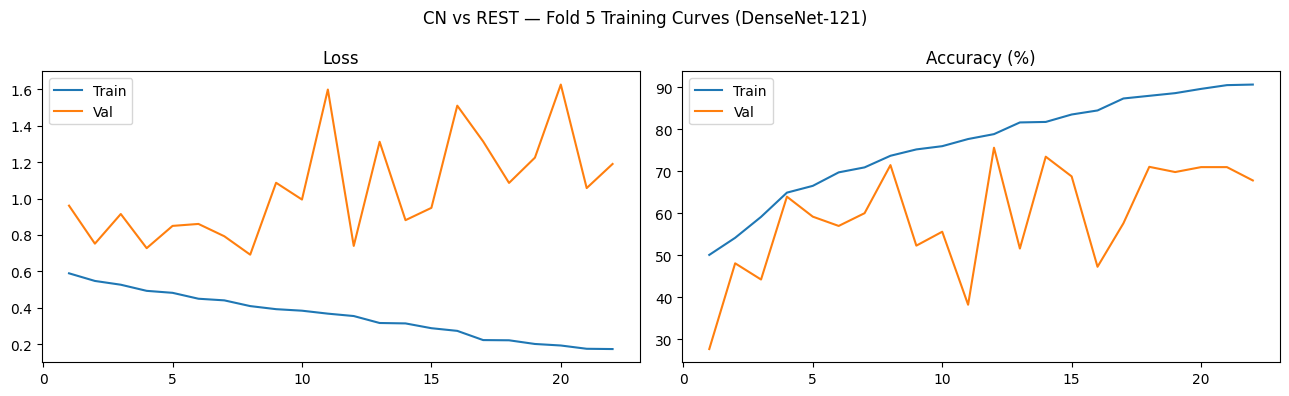

  Fold 5 — Patient-level val acc: 77.78%

  CN vs REST — 5-Fold CV Patient Acc: 75.45% ± 5.70%

  MCI vs REST  —  5-Fold Cross-Validation

  --- Fold 1/5 ---
  Train slices — MCI: 3222 | REST: 2565 | Val patients: 56


  Ep 01 | train loss=0.6892 acc=53.6% | val loss=0.6961 acc=51.9%
    ✓ Best val_acc=51.86% — saved.


  Ep 02 | train loss=0.6676 acc=56.9% | val loss=0.7230 acc=53.1%
    ✓ Best val_acc=53.08% — saved.


  Ep 03 | train loss=0.6408 acc=62.0% | val loss=0.7381 acc=53.3%
    ✓ Best val_acc=53.29% — saved.


  Ep 04 | train loss=0.6344 acc=62.7% | val loss=0.7761 acc=39.6%


...

  Ep 18 | train loss=0.4526 acc=78.6% | val loss=0.8920 acc=55.9%


  Ep 19 | train loss=0.4453 acc=78.1% | val loss=0.8995 acc=53.8%


  Ep 20 | train loss=0.4228 acc=80.8% | val loss=0.9109 acc=56.2%


  Ep 21 | train loss=0.3982 acc=81.9% | val loss=0.9454 acc=57.4%


  Ep 22 | train loss=0.4011 acc=81.3% | val loss=0.9430 acc=56.2%
    Early stopping at epoch 22.


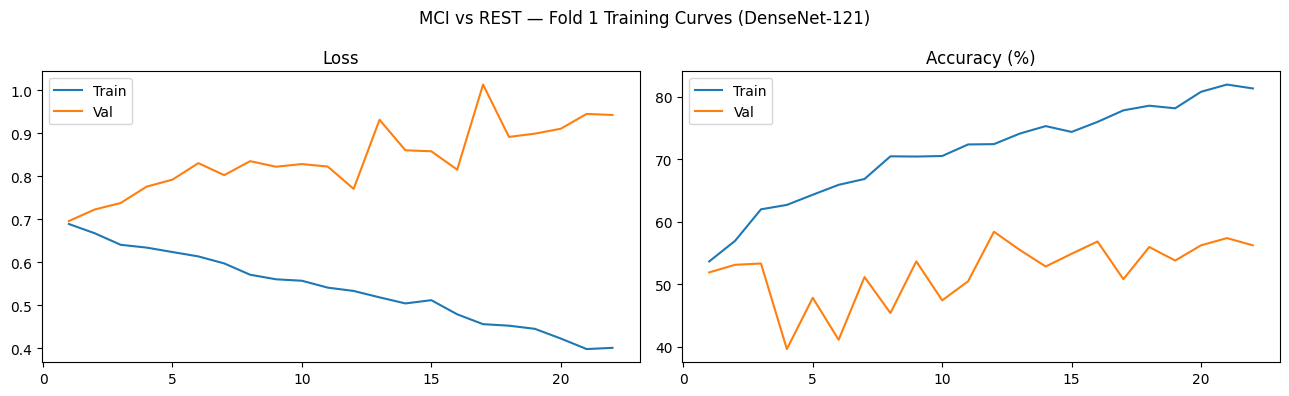

  Fold 1 — Patient-level val acc: 55.36%

  --- Fold 2/5 ---
  Train slices — MCI: 3212 | REST: 2583 | Val patients: 55


  Ep 01 | train loss=0.6796 acc=54.6% | val loss=0.7085 acc=53.8%
    ✓ Best val_acc=53.78% — saved.


  Ep 02 | train loss=0.6789 acc=55.1% | val loss=0.7684 acc=46.4%


  Ep 03 | train loss=0.6735 acc=57.4% | val loss=0.7197 acc=53.3%


  Ep 04 | train loss=0.6633 acc=58.5% | val loss=0.7073 acc=51.8%


...

  Ep 29 | train loss=0.3623 acc=84.3% | val loss=1.0609 acc=51.9%


  Ep 04 | train loss=0.6533 acc=59.5% | val loss=0.6539 acc=64.6%
    ✓ Best val_acc=64.59% — saved.


  Ep 07 | train loss=0.6173 acc=64.9% | val loss=0.7207 acc=62.3%


  Ep 08 | train loss=0.6079 acc=66.2% | val loss=0.6765 acc=61.3%


  Ep 14 | train loss=0.5100 acc=73.9% | val loss=0.8046 acc=60.2%
    Early stopping at epoch 14.


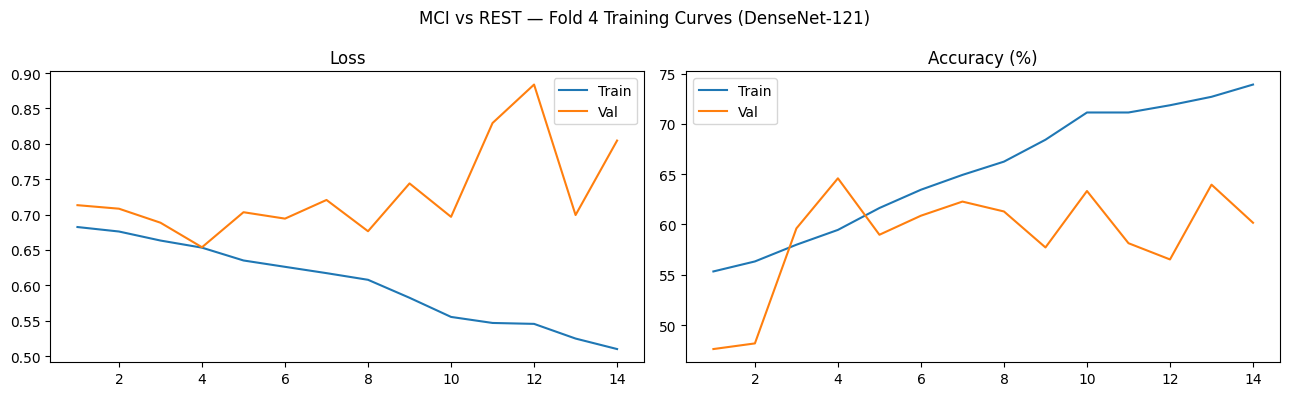

  Fold 4 — Patient-level val acc: 59.26%

  --- Fold 5/5 ---
  Train slices — MCI: 3235 | REST: 2579 | Val patients: 54


  Ep 01 | train loss=0.6844 acc=52.8% | val loss=0.6826 acc=56.4%
    ✓ Best val_acc=56.35% — saved.


  Ep 05 | train loss=0.6217 acc=64.9% | val loss=0.7599 acc=47.4%


  Ep 06 | train loss=0.6101 acc=65.6% | val loss=0.7336 acc=57.3%


Ep7/40 [train]:  24%|██▎       | 43/182 [00:07<00:24,  5.76it/s]

In [ ]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

trainval_by_class = defaultdict(list)
for pid in trainval_patients:
    trainval_by_class[clean_patients[pid]].append(pid)

for cls in CLASS_NAMES:
    random.shuffle(trainval_by_class[cls])

fold_results = {cls: [] for cls in CLASS_NAMES}
all_fold_ckpts = {cls: [] for cls in CLASS_NAMES}
all_fold_models = {cls: [] for cls in CLASS_NAMES}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    print(f"\n{'='*65}")
    print(f"  {pos_name} vs REST  —  {N_FOLDS}-Fold Cross-Validation")
    print(f"{'='*65}")

    binary_names = ["REST", pos_name]

    class_folds = {}
    for cls in CLASS_NAMES:
        pids = trainval_by_class[cls]
        folds = [pids[i::N_FOLDS] for i in range(N_FOLDS)]
        class_folds[cls] = folds

    for fold_idx in range(N_FOLDS):
        print(f"\n  --- Fold {fold_idx+1}/{N_FOLDS} ---")

        val_pids_fold = []
        for cls in CLASS_NAMES:
            val_pids_fold.extend(class_folds[cls][fold_idx])

        train_pids_fold = []
        for cls in CLASS_NAMES:
            for k, chunk in enumerate(class_folds[cls]):
                if k != fold_idx:
                    train_pids_fold.extend(chunk)

        def expand(pids):
            out = []
            for pid in pids:
                cls = clean_patients[pid]
                label = CLASS_NAMES.index(cls)
                for path in patient_slices[(pid, cls)]:
                    out.append((path, label, pid))
            return out

        train_entries_fold = expand(train_pids_fold)
        val_entries_fold = expand(val_pids_fold)

        def binarize(entries):
            return [(p, 1 if l == pos_class_idx else 0, pid)
                    for p, l, pid in entries]

        train_bin = binarize(train_entries_fold)
        val_bin = binarize(val_entries_fold)

        train_ds = SliceDataset(train_bin, augment=True)
        val_ds = SliceDataset(val_bin, augment=False)

        pos_count = sum(1 for _, l, _ in train_bin if l == 1)
        neg_count = len(train_bin) - pos_count
        print(f"  Train slices — {pos_name}: {pos_count} | REST: {neg_count} | "
              f"Val patients: {len(val_pids_fold)}")

        train_labels_list = train_ds.get_labels()
        if len(train_labels_list) == 0:
            raise RuntimeError(
                f"Fold {fold_idx+1} ({pos_name}): train_ds is empty! "
                f"Re-run Step 3 to rebuild the preprocessed cache."
            )

        cls_counts = Counter(train_labels_list)
        weights = [1.0 / cls_counts[l] for l in train_labels_list]
        sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                                  num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=2, pin_memory=True)

        # BUILD MODEL - DenseNet-121
        model = build_densenet121(num_classes=2).to(device)

        total_train = pos_count + neg_count
        class_weights = torch.tensor(
            [total_train / (2.0 * neg_count),
             total_train / (2.0 * pos_count)],
            dtype=torch.float32, device=device
        )
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        # Paper uses SGD optimizer with default settings
        optimizer = optim.SGD(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, momentum=0.9)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                         factor=0.5, patience=3)
        scaler = torch.amp.GradScaler()

        ckpt_path = os.path.join(CKPT_DIR, f"fold{fold_idx+1}_{pos_name}_vs_rest.pt")

        best_val_acc, patience_ctr = 0.0, 0
        history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

        for epoch in range(1, NUM_EPOCHS + 1):
            tr_loss, tr_acc = run_epoch(train_loader, model, criterion,
                                        optimizer, scaler,
                                        desc=f"Ep{epoch}/{NUM_EPOCHS} [train]")
            vl_loss, vl_acc = run_epoch(val_loader, model, criterion,
                                        desc=f"Ep{epoch}/{NUM_EPOCHS} [val]")

            history["train_loss"].append(tr_loss)
            history["train_acc"].append(tr_acc)
            history["val_loss"].append(vl_loss)
            history["val_acc"].append(vl_acc)

            scheduler.step(vl_acc)

            print(f"  Ep {epoch:02d} | "
                  f"train loss={tr_loss:.4f} acc={tr_acc*100:.1f}% | "
                  f"val loss={vl_loss:.4f} acc={vl_acc*100:.1f}%")

            if vl_acc > best_val_acc:
                best_val_acc = vl_acc
                torch.save(model.state_dict(), ckpt_path)
                patience_ctr = 0
                print(f"    ✓ Best val_acc={best_val_acc*100:.2f}% — saved.")
            else:
                patience_ctr += 1
                if patience_ctr >= PATIENCE:
                    print(f"    Early stopping at epoch {epoch}.")
                    break

        # Learning curves
        ep_range = range(1, len(history["train_loss"]) + 1)
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle(f"{pos_name} vs REST — Fold {fold_idx+1} Training Curves (DenseNet-121)")
        axes[0].plot(ep_range, history["train_loss"], label="Train")
        axes[0].plot(ep_range, history["val_loss"], label="Val")
        axes[0].set_title("Loss")
        axes[0].legend()
        axes[1].plot(ep_range, [a*100 for a in history["train_acc"]], label="Train")
        axes[1].plot(ep_range, [a*100 for a in history["val_acc"]], label="Val")
        axes[1].set_title("Accuracy (%)")
        axes[1].legend()
        plt.tight_layout()
        plt.savefig(os.path.join(CKPT_DIR,
                    f"curves_fold{fold_idx+1}_{pos_name}_vs_rest.png"), dpi=120)
        plt.show()

        # Load best weights, patient-level val accuracy
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        pat_acc, _, _ = patient_level_eval(val_loader, model, binary_names)
        print(f"  Fold {fold_idx+1} — Patient-level val acc: {pat_acc*100:.2f}%")

        fold_results[pos_name].append(pat_acc)
        all_fold_ckpts[pos_name].append(ckpt_path)

        model.to("cpu")
        model.eval()
        all_fold_models[pos_name].append(model)

        del optimizer, scaler, train_ds, val_ds
        torch.cuda.empty_cache()

    mean_acc = np.mean(fold_results[pos_name]) * 100
    std_acc = np.std(fold_results[pos_name]) * 100
    print(f"\n  {pos_name} vs REST — {N_FOLDS}-Fold CV Patient Acc: "
          f"{mean_acc:.2f}% ± {std_acc:.2f}%")

print("\n\nAll folds done.")

# Weighted Ensemble Evaluation On Hold-Out Test Set

  WEIGHTED ENSEMBLE — HOLD-OUT TEST EVALUATION (Patient-Level)

  AD vs REST
    Fold 1: val_acc=78.57%  weight=0.1923
    Fold 2: val_acc=83.64%  weight=0.2047
    Fold 3: val_acc=75.93%  weight=0.1859
    Fold 4: val_acc=83.33%  weight=0.2040
    Fold 5: val_acc=87.04%  weight=0.2131



  Weighted Ensemble Test Acc (AD vs REST): 80.85%  [47 patients]
              precision    recall  f1-score   support

        REST       0.86      0.92      0.89        39
          AD       0.40      0.25      0.31         8

    accuracy                           0.81        47
   macro avg       0.63      0.59      0.60        47
weighted avg       0.78      0.81      0.79        47



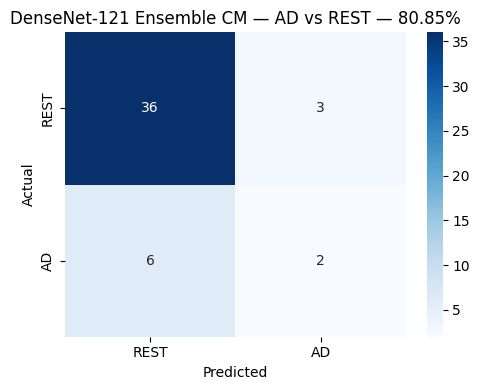


  CN vs REST
    Fold 1: val_acc=75.00%  weight=0.1988
    Fold 2: val_acc=78.18%  weight=0.2072
    Fold 3: val_acc=64.81%  weight=0.1718
    Fold 4: val_acc=81.48%  weight=0.2160
    Fold 5: val_acc=77.78%  weight=0.2062



  Weighted Ensemble Test Acc (CN vs REST): 72.34%  [47 patients]
              precision    recall  f1-score   support

        REST       0.78      0.85      0.82        34
          CN       0.50      0.38      0.43        13

    accuracy                           0.72        47
   macro avg       0.64      0.62      0.63        47
weighted avg       0.71      0.72      0.71        47



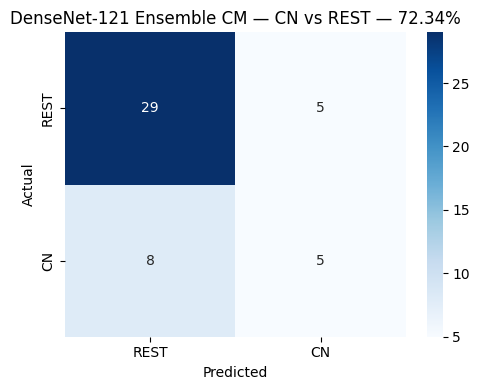


  MCI vs REST
    Fold 1: val_acc=55.36%  weight=0.1912
    Fold 2: val_acc=58.18%  weight=0.2010
    Fold 3: val_acc=59.26%  weight=0.2047
    Fold 4: val_acc=59.26%  weight=0.2047
    Fold 5: val_acc=57.41%  weight=0.1983



  Weighted Ensemble Test Acc (MCI vs REST): 51.06%  [47 patients]
              precision    recall  f1-score   support

        REST       0.47      0.71      0.57        21
         MCI       0.60      0.35      0.44        26

    accuracy                           0.51        47
   macro avg       0.53      0.53      0.50        47
weighted avg       0.54      0.51      0.50        47



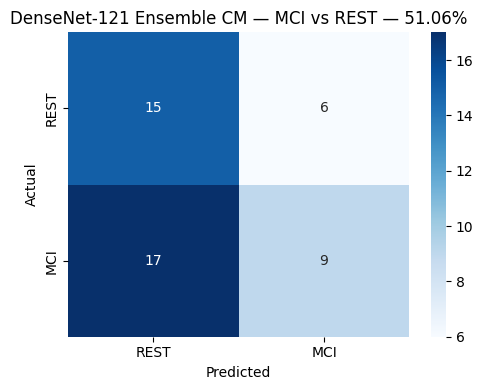

In [22]:
print(f"  WEIGHTED ENSEMBLE — HOLD-OUT TEST EVALUATION (Patient-Level)")
final_results = {}
pid_to_true_class = {pid: CLASS_NAMES[l] for p, l, pid in test_entries}
per_patient_records = defaultdict(dict)

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    binary_names = ["REST", pos_name]
    test_bin = [
        (p, 1 if l == pos_class_idx else 0, pid)
        for p, l, pid in test_entries
    ]
    test_ds = SliceDataset(test_bin, augment=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=True)
    fold_accs = np.array(fold_results[pos_name])
    fold_weights = fold_accs / fold_accs.sum()
    print(f"\n  {pos_name} vs REST")
    for fi, (acc, w) in enumerate(zip(fold_accs, fold_weights)):
        print(f"    Fold {fi+1}: val_acc={acc*100:.2f}%  weight={w:.4f}")

    fold_models = all_fold_models[pos_name]
    for m in fold_models:
        m.to(device)
        m.eval()

    patient_probs = defaultdict(lambda: np.zeros(2))
    patient_labels = {}

    with torch.no_grad():
        for images, labels, pids in tqdm(test_loader,
                                         desc=f"{pos_name} — Ensemble Eval",
                                         leave=False):
            images = images.to(device, non_blocking=True)
            batch_weighted_probs = np.zeros((images.size(0), 2))
            for fold_model, w in zip(fold_models, fold_weights):
                with torch.amp.autocast(device_type="cuda"):
                    logits = fold_model(images)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                batch_weighted_probs += w * probs
            for wp, label, pid in zip(batch_weighted_probs, labels.numpy(), pids):
                patient_probs[pid] += wp
                patient_labels[pid] = int(label)

    for pid, wp_sum in patient_probs.items():
        conf = wp_sum[1] / wp_sum.sum()
        per_patient_records[pid]["true_class"] = pid_to_true_class[pid]
        per_patient_records[pid][f"{pos_name}_positive_call"] = int(np.argmax(wp_sum))
        per_patient_records[pid][f"{pos_name}_confidence"] = float(conf)

    all_true, all_pred = [], []
    for pid, wp_sum in patient_probs.items():
        all_true.append(patient_labels[pid])
        all_pred.append(int(np.argmax(wp_sum)))
    pat_acc = np.mean(np.array(all_true) == np.array(all_pred))
    print(f"\n  Weighted Ensemble Test Acc ({pos_name} vs REST): "
          f"{pat_acc*100:.2f}%  [{len(patient_probs)} patients]")
    print(classification_report(all_true, all_pred, target_names=binary_names))

    cm = confusion_matrix(all_true, all_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=binary_names, yticklabels=binary_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"DenseNet-121 Ensemble CM — {pos_name} vs REST — {pat_acc*100:.2f}%")
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f"cm_ensemble_{pos_name}_vs_rest.png"), dpi=150)
    plt.show()

    final_results[pos_name] = {
        "patient_test_acc": pat_acc,
        "cv_mean_acc": float(np.mean(fold_accs)),
        "cv_std_acc": float(np.std(fold_accs)),
        "fold_weights": fold_weights.tolist(),
    }
    for m in fold_models:
        m.to("cpu")
    torch.cuda.empty_cache()

# Summary & Saving Results

In [25]:
print(f"  FINAL SUMMARY — DENSENET-121 WEIGHTED ENSEMBLE")
print(f"  {'Class':<8} {'CV Acc (mean±std)':<24} {'Ensemble Test Acc (patient-level)'}")
print(f"  {'-'*65}")
for cls, res in final_results.items():
    cv_str = f"{res['cv_mean_acc']*100:.2f}% ± {res['cv_std_acc']*100:.2f}%"
    test_str = f"{res['patient_test_acc']*100:.2f}%"
    print(f"  {cls:<8} {cv_str:<24} {test_str}")

csv_path = os.path.join(CKPT_DIR, "results_densenet121_weighted_ensemble.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "class", "cv_mean_acc_%", "cv_std_%", "ensemble_test_acc_%", "fold_weights"
    ])
    writer.writeheader()
    for cls, res in final_results.items():
        writer.writerow({
            "class": cls,
            "cv_mean_acc_%": round(res["cv_mean_acc"] * 100, 2),
            "cv_std_%": round(res["cv_std_acc"] * 100, 2),
            "ensemble_test_acc_%": round(res["patient_test_acc"] * 100, 2),
            "fold_weights": str([round(w, 4) for w in res["fold_weights"]]),
        })
print(f"\n  Results saved -> {csv_path}")

pp_csv_path = os.path.join(CKPT_DIR, "per_patient_densenet121_predictions.csv")
fieldnames = ["patient_id", "true_class"] + [f"{c}_{k}" for c in CLASS_NAMES for k in ("positive_call", "confidence")]
with open(pp_csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for pid, rec in per_patient_records.items():
        row = {"patient_id": pid, "true_class": rec["true_class"]}
        for c in CLASS_NAMES:
            row[f"{c}_positive_call"] = rec.get(f"{c}_positive_call")
            row[f"{c}_confidence"] = rec.get(f"{c}_confidence")
        writer.writerow(row)
print(f"Saved {len(per_patient_records)} DenseNet-121 patient records to {pp_csv_path}")

  FINAL SUMMARY — DENSENET-121 WEIGHTED ENSEMBLE
  Class    CV Acc (mean±std)        Ensemble Test Acc (patient-level)
  -----------------------------------------------------------------
  AD       81.70% ± 3.95%           80.85%
  CN       75.45% ± 5.70%           72.34%
  MCI      57.89% ± 1.45%           51.06%

  Results saved -> /kaggle/working/checkpoints_densenet121_patientlevel/results_densenet121_weighted_ensemble.csv
Saved 47 DenseNet-121 patient records to /kaggle/working/checkpoints_densenet121_patientlevel/per_patient_densenet121_predictions.csv


In [27]:
import os
import shutil
from IPython.display import FileLink, display

# ── Option A: zip everything in /kaggle/working ──────────────────────────
WORKING_DIR = '/kaggle/working'
ZIP_NAME    = '/kaggle/working/all_outputs'   # .zip added automatically

# Exclude the zip itself (and any previous zips) from being re-zipped into itself
def _zip_filter(dirpath, filenames):
    return [f for f in filenames if f.endswith('.zip')]

shutil.make_archive(
    base_name=ZIP_NAME,
    format='zip',
    root_dir=WORKING_DIR
)

zip_path = ZIP_NAME + '.zip'
size_mb  = os.path.getsize(zip_path) / 1e6
print(f'Zipped -> {zip_path}  ({size_mb:.1f} MB)')

display(FileLink(zip_path))

Zipped -> /kaggle/working/all_outputs.zip  (1534.2 MB)


/kaggle/working/all_outputs.zip